# 02 — Stylised Loan Portfolio Construction

**Purpose**: Build the stylised loan portfolio that underpins all four financial decision simulations.

**Input**: Clean property data and triangular fitted distributions from Notebook 01.

**Output**: `data/processed/portfolio.csv` — one row per loan/property.

**Design — LTV-based structural model (primary)**:
- Primary state variables are LTV₀ (loan-to-value at origination) and PV₀ (property value)
- EAD, baseline PD, and baseline LGD are all **derived** from LTV₀ and PV₀ — not drawn independently
- This creates a structurally coherent portfolio where credit risk characteristics are grounded in the collateral channel (Deng et al. 2000; Qi & Yang 2009; Ferretti et al. 2023)
- Heterogeneity in LTV₀ drives heterogeneity in SICR sensitivity: high-LTV loans are closer to the staging boundary

**Reduced-form model (sensitivity)**:
- Independent EAD, baseline PD, baseline LGD draws are also generated and stored as `*_rf` columns
- Used only in Notebook 05 (sensitivity analysis) to confirm results hold under an alternative transmission model

**Zero-damage properties** (20/100) are included as loans with no climate-driven uncertainty.

This notebook is **shared infrastructure** — the saved portfolio is loaded by all decision-specific notebooks.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import yaml
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path(".").resolve().parent.parent / "src"))

from portfolio.construction import build_portfolio
from utils.plotting import set_style, COLOURS

set_style()

# Ensure output directories exist
Path("../../outputs/figures/shared").mkdir(parents=True, exist_ok=True)
Path("../../data/processed").mkdir(parents=True, exist_ok=True)

# Load config
with open("../../config/parameters.yaml", "r") as f:
    config = yaml.safe_load(f)

print("Config loaded. Portfolio seed:", config["portfolio"]["random_seed"])

Config loaded. Portfolio seed: 42


## 1. Load data from Notebook 01

In [2]:
# Clean property data
df = pd.read_csv("../../data/processed/cfrf_garp_clean.csv")
print(f"Properties loaded: {len(df)}")

# Triangular fit results (primary distribution)
fit_results = pd.read_csv("../../data/processed/fitted_distributions_triangular.csv")
print(f"Fit results loaded: {len(fit_results)} rows")

assert len(df) == len(fit_results), "Row count mismatch between data and fit results"

# Summarise physical risk coverage
zero_mask = fit_results["is_zero_damage"]
print(f"\nZero-damage properties:         {zero_mask.sum()} (included as point masses)")
print(f"Properties with uncertainty:    {(~zero_mask).sum()}")

Properties loaded: 100
Fit results loaded: 100 rows

Zero-damage properties:         20 (included as point masses)
Properties with uncertainty:    80


## 2. Build the portfolio

In [3]:
portfolio = build_portfolio(config, df, fit_results)

print(f"Portfolio size: {len(portfolio)} loans")
print(f"\nPrimary draws:   ltv_0, pv_0_m, maturity_years")
print(f"Derived (LTV):   ead_m, baseline_pd_12m, baseline_lgd, baseline_pd_lt, baseline_ecl_m, d_sicr_threshold")
print(f"Sensitivity RF:  ead_rf_m, baseline_pd_rf, baseline_lgd_rf, baseline_pd_lt_rf, baseline_ecl_rf_m")
print(f"\nAll columns: {list(portfolio.columns)}")
print("\nSample (first 5 rows — LTV-structural columns):")
cols_show = ["property_rank", "ltv_0", "pv_0_m", "ead_m", "maturity_years",
             "baseline_pd_12m", "baseline_lgd", "baseline_ecl_m", "d_sicr_threshold"]
portfolio[cols_show].head()

Portfolio size: 100 loans

Primary draws:   ltv_0, pv_0_m, maturity_years
Derived (LTV):   ead_m, baseline_pd_12m, baseline_lgd, baseline_pd_lt, baseline_ecl_m, d_sicr_threshold
Sensitivity RF:  ead_rf_m, baseline_pd_rf, baseline_lgd_rf, baseline_pd_lt_rf, baseline_ecl_rf_m

All columns: ['property_rank', 'd_min', 'd_mean', 'd_max', 'vendor_spread', 'is_zero_damage', 'tri_mode', 'tri_clamped', 'ltv_0', 'pv_0_m', 'maturity_years', 'ead_m', 'baseline_pd_12m', 'baseline_lgd', 'baseline_pd_lt', 'baseline_ecl_m', 'd_sicr_threshold', 'd_sicr_uncond', 'ead_rf_m', 'baseline_pd_rf', 'baseline_lgd_rf', 'baseline_pd_lt_rf', 'baseline_ecl_rf_m']

Sample (first 5 rows — LTV-structural columns):


,property_rank,ltv_0,pv_0_m,ead_m,maturity_years,baseline_pd_12m,baseline_lgd,baseline_ecl_m,d_sicr_threshold
0,1,0.832187,0.672418,0.559578,24,0.007826,0.098760,0.000432,0.108277
1,2,0.731664,0.712376,0.521219,15,0.003517,0.000000,0.000000,0.109876
2,3,0.857579,0.415831,0.356608,19,0.009571,0.125445,0.000428,0.105066
3,4,0.809210,0.560002,0.453160,14,0.006520,0.073171,0.000216,0.103325
4,5,0.628253,0.438344,0.275391,10,0.001541,0.000000,0.000000,0.122514


In [4]:
print("=== Portfolio summary statistics ===")

print(f"\nLTV at origination (LTV₀):")
print(f"  Mean:   {portfolio.ltv_0.mean():.3f}   Median: {portfolio.ltv_0.median():.3f}")
print(f"  Range:  {portfolio.ltv_0.min():.3f} – {portfolio.ltv_0.max():.3f}")

print(f"\nProperty value (PV₀, £m):")
print(f"  Median: £{portfolio.pv_0_m.median():.2f}m   Mean: £{portfolio.pv_0_m.mean():.2f}m")
print(f"  Range:  £{portfolio.pv_0_m.min():.2f}m – £{portfolio.pv_0_m.max():.2f}m")

print(f"\nEAD = LTV₀ × PV₀ (£m):")
print(f"  Mean:   £{portfolio.ead_m.mean():.2f}m   Median: £{portfolio.ead_m.median():.2f}m")
print(f"  Range:  £{portfolio.ead_m.min():.2f}m – £{portfolio.ead_m.max():.2f}m")
print(f"  Total:  £{portfolio.ead_m.sum():.1f}m")

print(f"\nMaturity (years):")
print(f"  Mean:   {portfolio.maturity_years.mean():.1f}   Range: {portfolio.maturity_years.min()} – {portfolio.maturity_years.max()}")

print(f"\nBaseline PD_12m (derived from logistic at LTV₀):")
print(f"  Median: {portfolio.baseline_pd_12m.median()*100:.3f}%")
print(f"  Range:  {portfolio.baseline_pd_12m.min()*100:.3f}% – {portfolio.baseline_pd_12m.max()*100:.3f}%")

print(f"\nBaseline LGD (collateral shortfall at d=0):")
n_zero_lgd = (portfolio.baseline_lgd == 0).sum()
print(f"  Mean:   {portfolio.baseline_lgd.mean():.3f}   Range: {portfolio.baseline_lgd.min():.3f} – {portfolio.baseline_lgd.max():.3f}")
print(f"  Loans with LGD=0 (LTV₀ < 1−ω):  {n_zero_lgd}")
print(f"  Note: LGD=0 when LTV₀ < {1 - config['decision1_credit_risk']['ltv_structural']['omega']:.2f} (collateral > debt after workout costs)")

print(f"\nBaseline ECL (Stage 1, pre-climate):")
print(f"  Total:  £{portfolio.baseline_ecl_m.sum()*1000:.1f}k")
print(f"  As % of total EAD:  {portfolio.baseline_ecl_m.sum() / portfolio.ead_m.sum() * 100:.4f}%")

print(f"\nSICR damage threshold (d*):")
n_reachable = portfolio.d_sicr_threshold.notna().sum()
print(f"  Reachable (d* ≤ 1):  {n_reachable} loans")
print(f"  Unreachable (d* > 1): {100 - n_reachable} loans")
print(f"  Median d* (reachable): {portfolio.d_sicr_threshold.median():.3f}")

=== Portfolio summary statistics ===

LTV at origination (LTV₀):
  Mean:   0.746   Median: 0.740
  Range:  0.602 – 0.893

Property value (PV₀, £m):
  Median: £0.81m   Mean: £0.93m
  Range:  £0.29m – £2.22m

EAD = LTV₀ × PV₀ (£m):
  Mean:   £0.69m   Median: £0.60m
  Range:  £0.21m – £1.76m
  Total:  £69.3m

Maturity (years):
  Mean:   14.6   Range: 5 – 25

Baseline PD_12m (derived from logistic at LTV₀):
  Median: 0.377%
  Range:  0.125% – 1.264%

Baseline LGD (collateral shortfall at d=0):
  Mean:   0.040   Range: 0.000 – 0.160
  Loans with LGD=0 (LTV₀ < 1−ω):  53
  Note: LGD=0 when LTV₀ < 0.75 (collateral > debt after workout costs)

Baseline ECL (Stage 1, pre-climate):
  Total:  £26.5k
  As % of total EAD:  0.0383%

SICR damage threshold (d*):
  Reachable (d* ≤ 1):  100 loans
  Unreachable (d* > 1): 0 loans
  Median d* (reachable): 0.109


## 3. Diagnostic plots — loan characteristics (LTV-structural model)

The primary draws are LTV₀ and PV₀. EAD is their product. Baseline PD and LGD are derived from LTV₀ via the logistic and collateral shortfall formulas respectively — they are outputs of the structural model, not independent draws.

C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\3868726627.py:82: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\3868726627.py:82: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\3868726627.py:83: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/shared/portfolio_loan_characteristics.png", dpi=300,
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\3868726627.py:83: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/shared/portfolio_loan_characteristics.png", dpi=300,
C:\Users\Mark.DESKTOP-UFHIN6T\anaconda3\envs\garp-climate-risk\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}

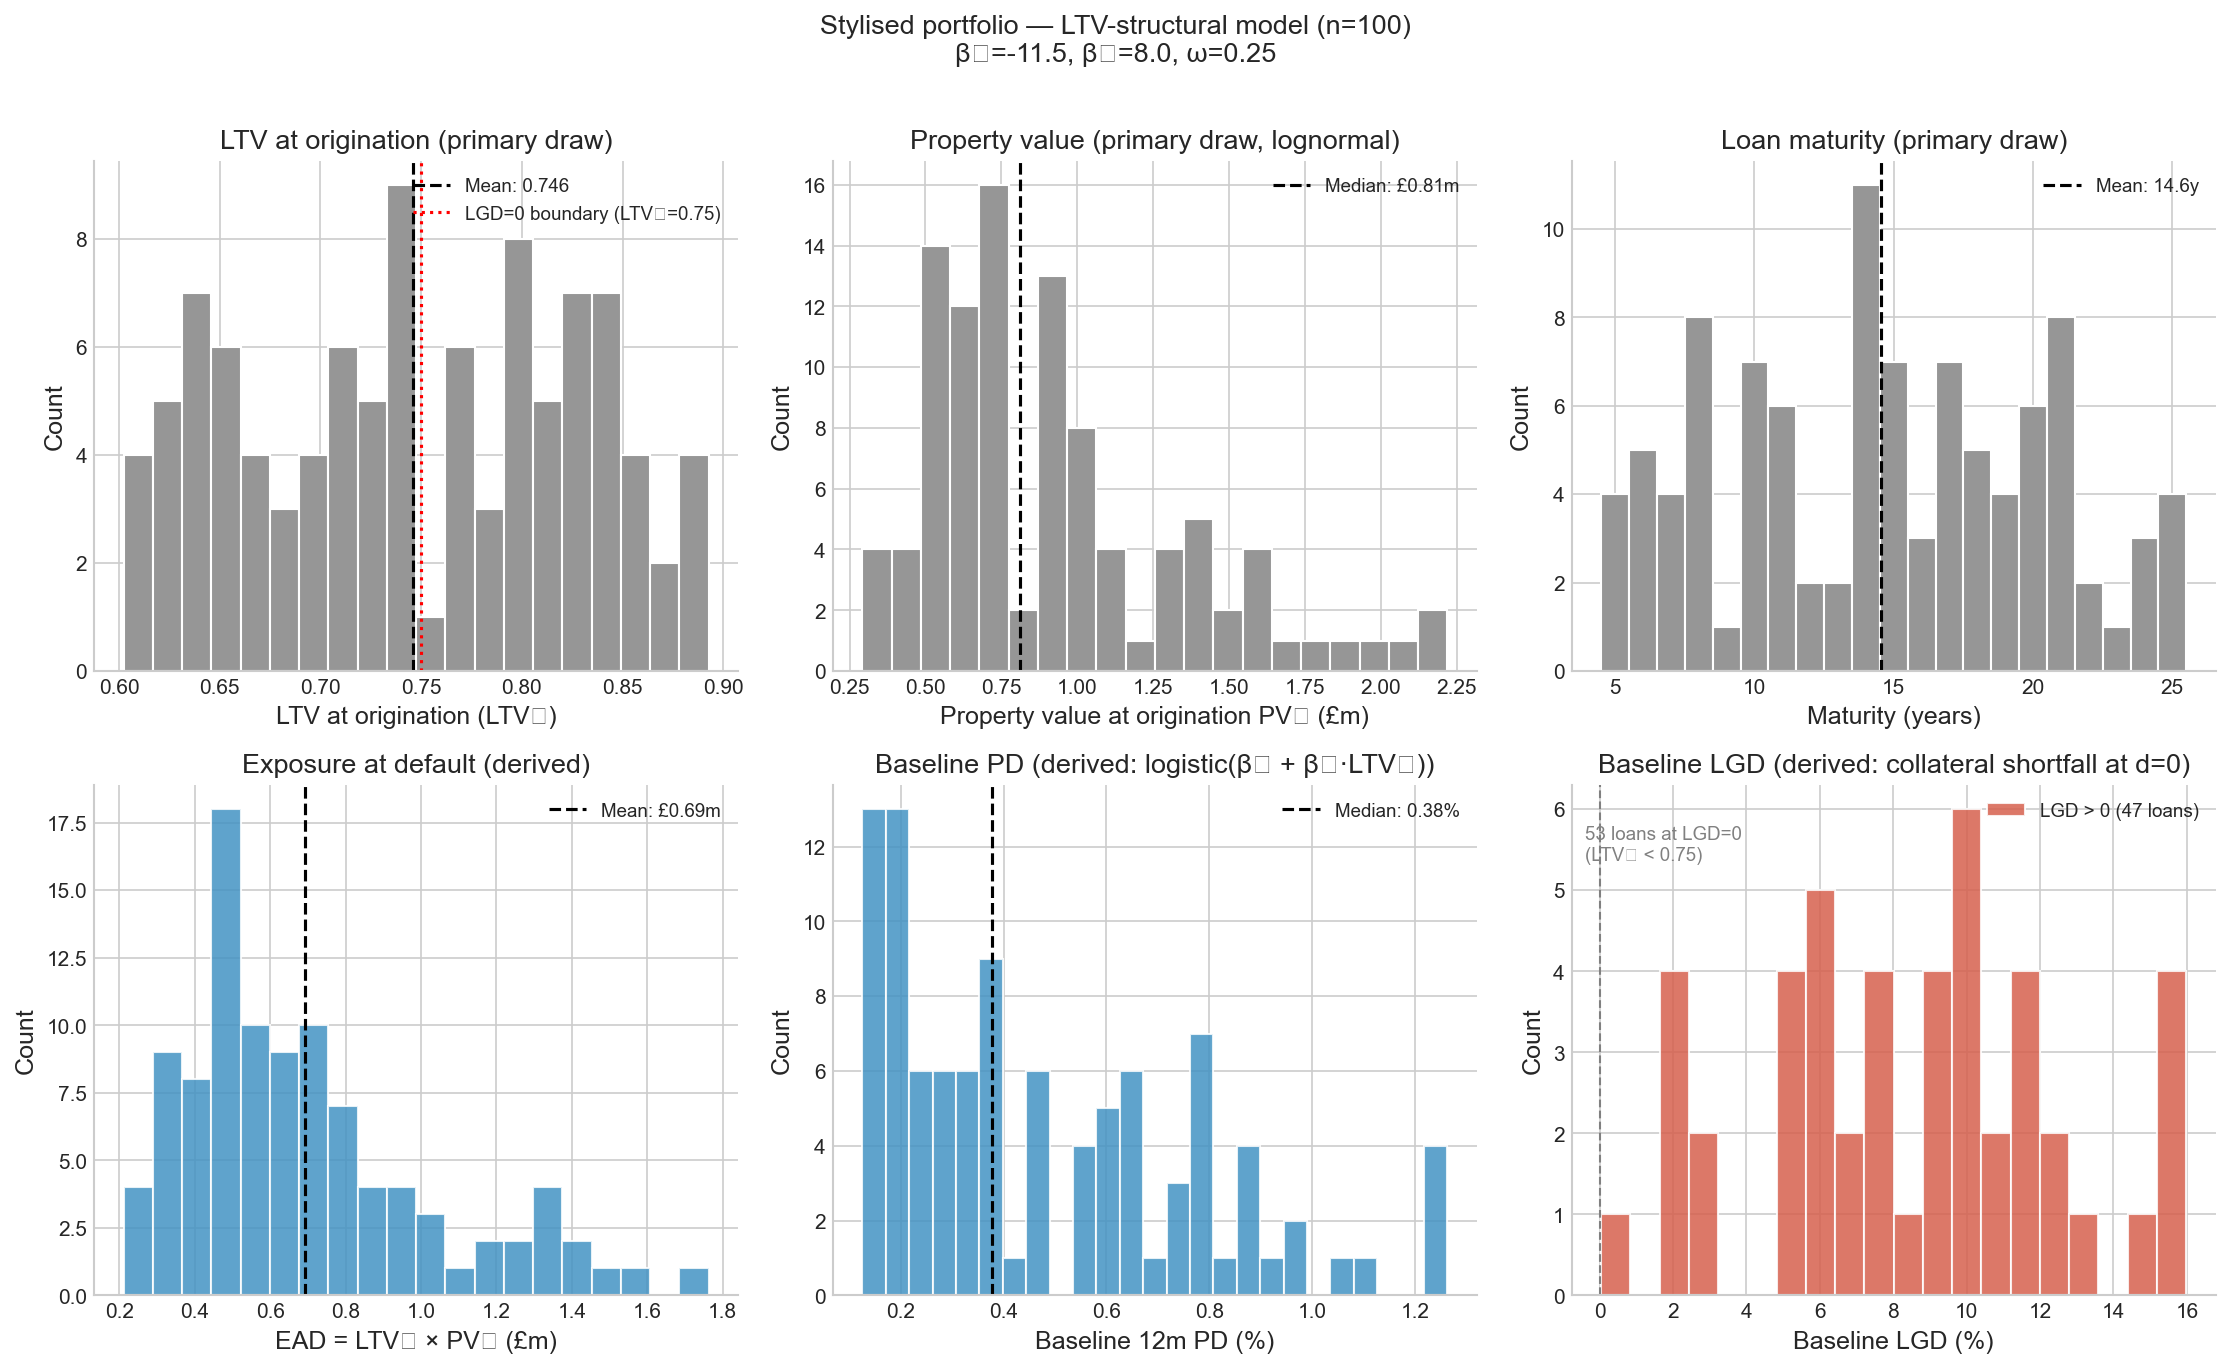

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

cfg_ltv = config["decision1_credit_risk"]["ltv_structural"]
beta_0, beta_1, omega = cfg_ltv["beta_0"], cfg_ltv["beta_1"], cfg_ltv["omega"]

# --- Panel 1: LTV₀ distribution ---
ax = axes[0]
ax.hist(portfolio.ltv_0, bins=20, color=COLOURS["grey"], edgecolor="white")
ax.axvline(portfolio.ltv_0.mean(), color="k", lw=1.5, ls="--",
           label=f"Mean: {portfolio.ltv_0.mean():.3f}")
ax.axvline(1 - omega, color="red", lw=1.5, ls=":",
           label=f"LGD=0 boundary (LTV₀={1-omega:.2f})")
ax.set_xlabel("LTV at origination (LTV₀)")
ax.set_ylabel("Count")
ax.set_title("LTV at origination (primary draw)")
ax.legend(fontsize=9)

# --- Panel 2: PV₀ distribution ---
ax = axes[1]
ax.hist(portfolio.pv_0_m, bins=20, color=COLOURS["grey"], edgecolor="white")
ax.axvline(portfolio.pv_0_m.median(), color="k", lw=1.5, ls="--",
           label=f"Median: £{portfolio.pv_0_m.median():.2f}m")
ax.set_xlabel("Property value at origination PV₀ (£m)")
ax.set_ylabel("Count")
ax.set_title("Property value (primary draw, lognormal)")
ax.legend(fontsize=9)

# --- Panel 3: Maturity ---
ax = axes[2]
ax.hist(portfolio.maturity_years, bins=range(5, 27), color=COLOURS["grey"],
        edgecolor="white", align="left")
ax.axvline(portfolio.maturity_years.mean(), color="k", lw=1.5, ls="--",
           label=f"Mean: {portfolio.maturity_years.mean():.1f}y")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Count")
ax.set_title("Loan maturity (primary draw)")
ax.legend(fontsize=9)

# --- Panel 4: EAD (derived) ---
ax = axes[3]
ax.hist(portfolio.ead_m, bins=20, color=COLOURS["stage1"], edgecolor="white", alpha=0.85)
ax.axvline(portfolio.ead_m.mean(), color="k", lw=1.5, ls="--",
           label=f"Mean: £{portfolio.ead_m.mean():.2f}m")
ax.set_xlabel("EAD = LTV₀ × PV₀ (£m)")
ax.set_ylabel("Count")
ax.set_title("Exposure at default (derived)")
ax.legend(fontsize=9)

# --- Panel 5: Baseline PD (derived from logistic at LTV₀) ---
ax = axes[4]
ax.hist(portfolio.baseline_pd_12m * 100, bins=25, color=COLOURS["stage1"],
        edgecolor="white", alpha=0.85)
ax.axvline(portfolio.baseline_pd_12m.median() * 100, color="k", lw=1.5, ls="--",
           label=f"Median: {portfolio.baseline_pd_12m.median()*100:.2f}%")
ax.set_xlabel("Baseline 12m PD (%)")
ax.set_ylabel("Count")
ax.set_title("Baseline PD (derived: logistic(β₀ + β₁·LTV₀))")
ax.legend(fontsize=9)

# --- Panel 6: Baseline LGD (derived from collateral shortfall at d=0) ---
ax = axes[5]
# Split into zero and non-zero LGD for clarity
zero_lgd = (portfolio.baseline_lgd == 0)
ax.hist(portfolio.loc[~zero_lgd, "baseline_lgd"] * 100, bins=20,
        color=COLOURS["stage2"], edgecolor="white", alpha=0.85,
        label=f"LGD > 0 ({(~zero_lgd).sum()} loans)")
ax.axvline(0, color="grey", lw=1, ls="--")
n_zero = zero_lgd.sum()
ax.text(0.02, 0.92, f"{n_zero} loans at LGD=0\n(LTV₀ < {1-omega:.2f})",
        transform=ax.transAxes, fontsize=9, va="top", color="grey")
ax.set_xlabel("Baseline LGD (%)")
ax.set_ylabel("Count")
ax.set_title("Baseline LGD (derived: collateral shortfall at d=0)")
ax.legend(fontsize=9)

fig.suptitle(
    f"Stylised portfolio — LTV-structural model (n=100)\n"
    f"β₀={beta_0}, β₁={beta_1}, ω={omega}",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig("../../outputs/figures/shared/portfolio_loan_characteristics.png", dpi=300,
            bbox_inches="tight")
plt.show()

## 4. Structural model curves — PD and LGD as functions of LTV

This plot verifies the calibration of the logistic PD and collateral shortfall LGD against the literature targets, and shows the portfolio loans' positions on those curves.

C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\2740842719.py:46: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\2740842719.py:46: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\2740842719.py:46: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\2740842719.py:47: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/shared/portfolio_structural_model_curves.png", dpi=300,
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\2740842719.py:47: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/shared/portfolio_structural_mo

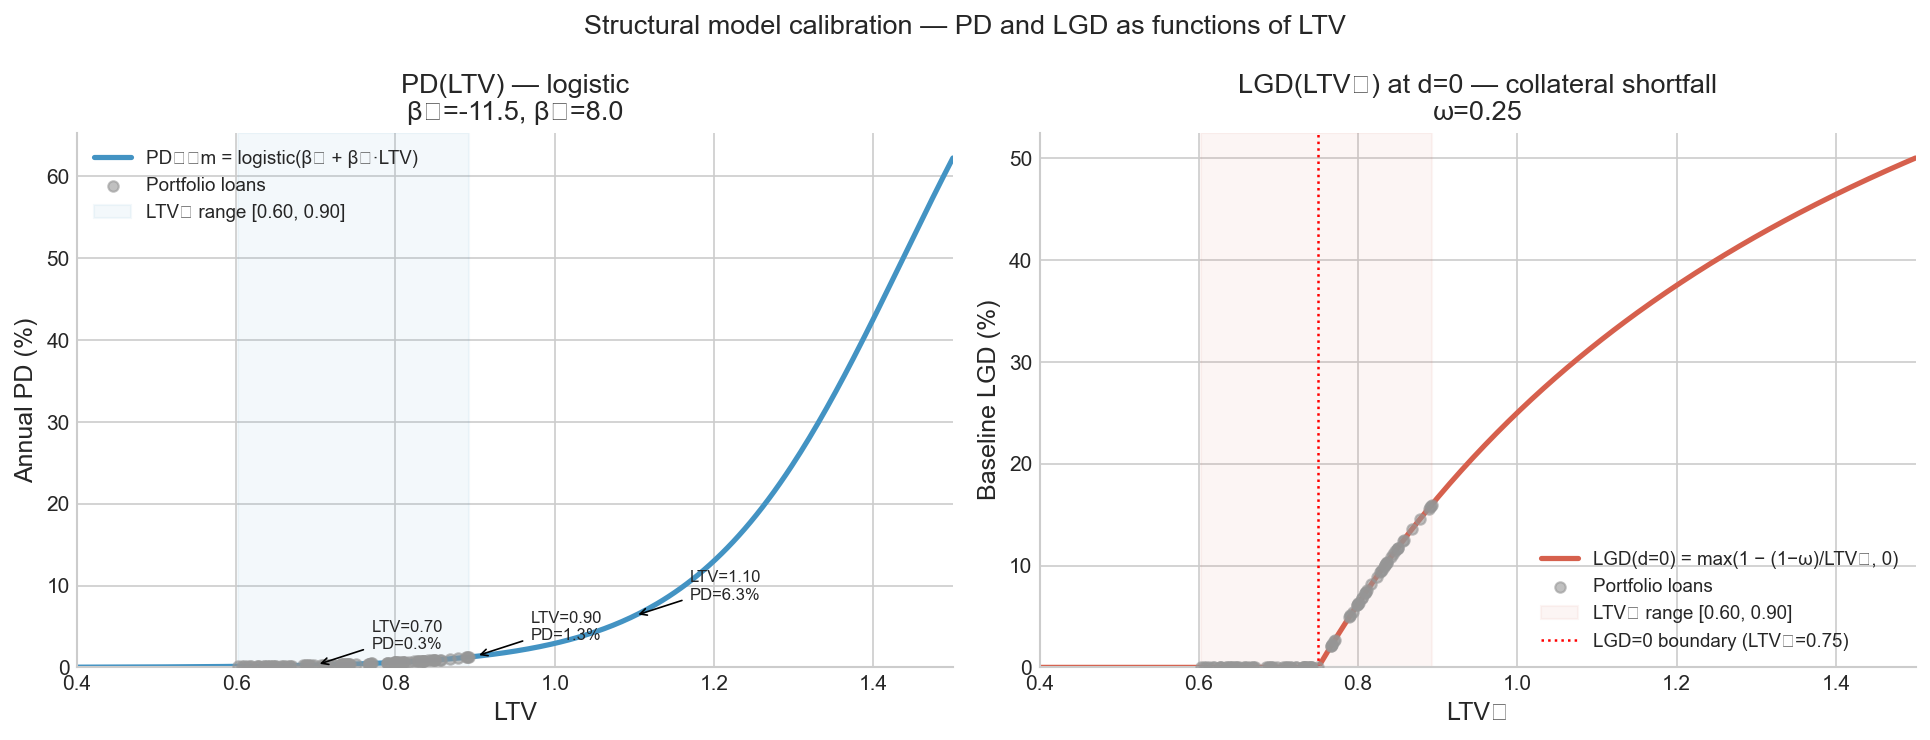

=== PD calibration check ===
  LTV=0.60:  PD=0.12%   LGD=0.0%
  LTV=0.70:  PD=0.27%   LGD=0.0%
  LTV=0.75:  PD=0.41%   LGD=0.0%
  LTV=0.80:  PD=0.61%   LGD=6.2%
  LTV=0.85:  PD=0.90%   LGD=11.8%
  LTV=0.90:  PD=1.34%   LGD=16.7%
  LTV=1.00:  PD=2.93%   LGD=25.0%
  LTV=1.10:  PD=6.30%   LGD=31.8%


In [6]:
ltv_grid = np.linspace(0.4, 1.5, 300)
pd_curve  = 1.0 / (1.0 + np.exp(-(beta_0 + beta_1 * ltv_grid)))
lgd_curve = np.maximum(1.0 - (1.0 - omega) / ltv_grid, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: PD curve ---
ax = axes[0]
ax.plot(ltv_grid, pd_curve * 100, color=COLOURS["stage1"], lw=2.5, label="PD₁₂m = logistic(β₀ + β₁·LTV)")
ax.scatter(portfolio.ltv_0, portfolio.baseline_pd_12m * 100,
           s=25, color=COLOURS["grey"], alpha=0.6, zorder=3, label="Portfolio loans")
ax.axvspan(portfolio.ltv_0.min(), portfolio.ltv_0.max(), alpha=0.06,
           color=COLOURS["stage1"], label="LTV₀ range [0.60, 0.90]")
ax.set_xlabel("LTV")
ax.set_ylabel("Annual PD (%)")
ax.set_title(f"PD(LTV) — logistic\nβ₀={beta_0}, β₁={beta_1}")
ax.legend(fontsize=9)
ax.set_xlim(0.4, 1.5)
ax.set_ylim(bottom=0)

# Annotate key calibration points
for ltv_mark, label in [(0.70, "0.70"), (0.90, "0.90"), (1.10, "1.10")]:
    pd_mark = 1.0 / (1.0 + np.exp(-(beta_0 + beta_1 * ltv_mark)))
    ax.annotate(f"LTV={label}\nPD={pd_mark*100:.1f}%",
                xy=(ltv_mark, pd_mark * 100), xytext=(ltv_mark + 0.07, pd_mark * 100 + 2),
                fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.8),
                ha="left")

# --- Right: LGD curve ---
ax = axes[1]
ax.plot(ltv_grid, lgd_curve * 100, color=COLOURS["stage2"], lw=2.5,
        label="LGD(d=0) = max(1 − (1−ω)/LTV₀, 0)")
ax.scatter(portfolio.ltv_0, portfolio.baseline_lgd * 100,
           s=25, color=COLOURS["grey"], alpha=0.6, zorder=3, label="Portfolio loans")
ax.axvspan(portfolio.ltv_0.min(), portfolio.ltv_0.max(), alpha=0.06,
           color=COLOURS["stage2"], label="LTV₀ range [0.60, 0.90]")
ax.axvline(1 - omega, color="red", lw=1.2, ls=":", label=f"LGD=0 boundary (LTV₀={1-omega:.2f})")
ax.set_xlabel("LTV₀")
ax.set_ylabel("Baseline LGD (%)")
ax.set_title(f"LGD(LTV₀) at d=0 — collateral shortfall\nω={omega}")
ax.legend(fontsize=9)
ax.set_xlim(0.4, 1.5)
ax.set_ylim(bottom=0)

fig.suptitle("Structural model calibration — PD and LGD as functions of LTV", fontsize=13)
plt.tight_layout()
plt.savefig("../../outputs/figures/shared/portfolio_structural_model_curves.png", dpi=300,
            bbox_inches="tight")
plt.show()

# Print key calibration values for verification
print("=== PD calibration check ===")
for ltv_mark in [0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 1.00, 1.10]:
    pd_val = 1.0 / (1.0 + np.exp(-(beta_0 + beta_1 * ltv_mark)))
    lgd_val = max(1.0 - (1.0 - omega) / ltv_mark, 0.0)
    print(f"  LTV={ltv_mark:.2f}:  PD={pd_val*100:.2f}%   LGD={lgd_val*100:.1f}%")

## 5. Physical risk profile — vendor damage ratio dispersion

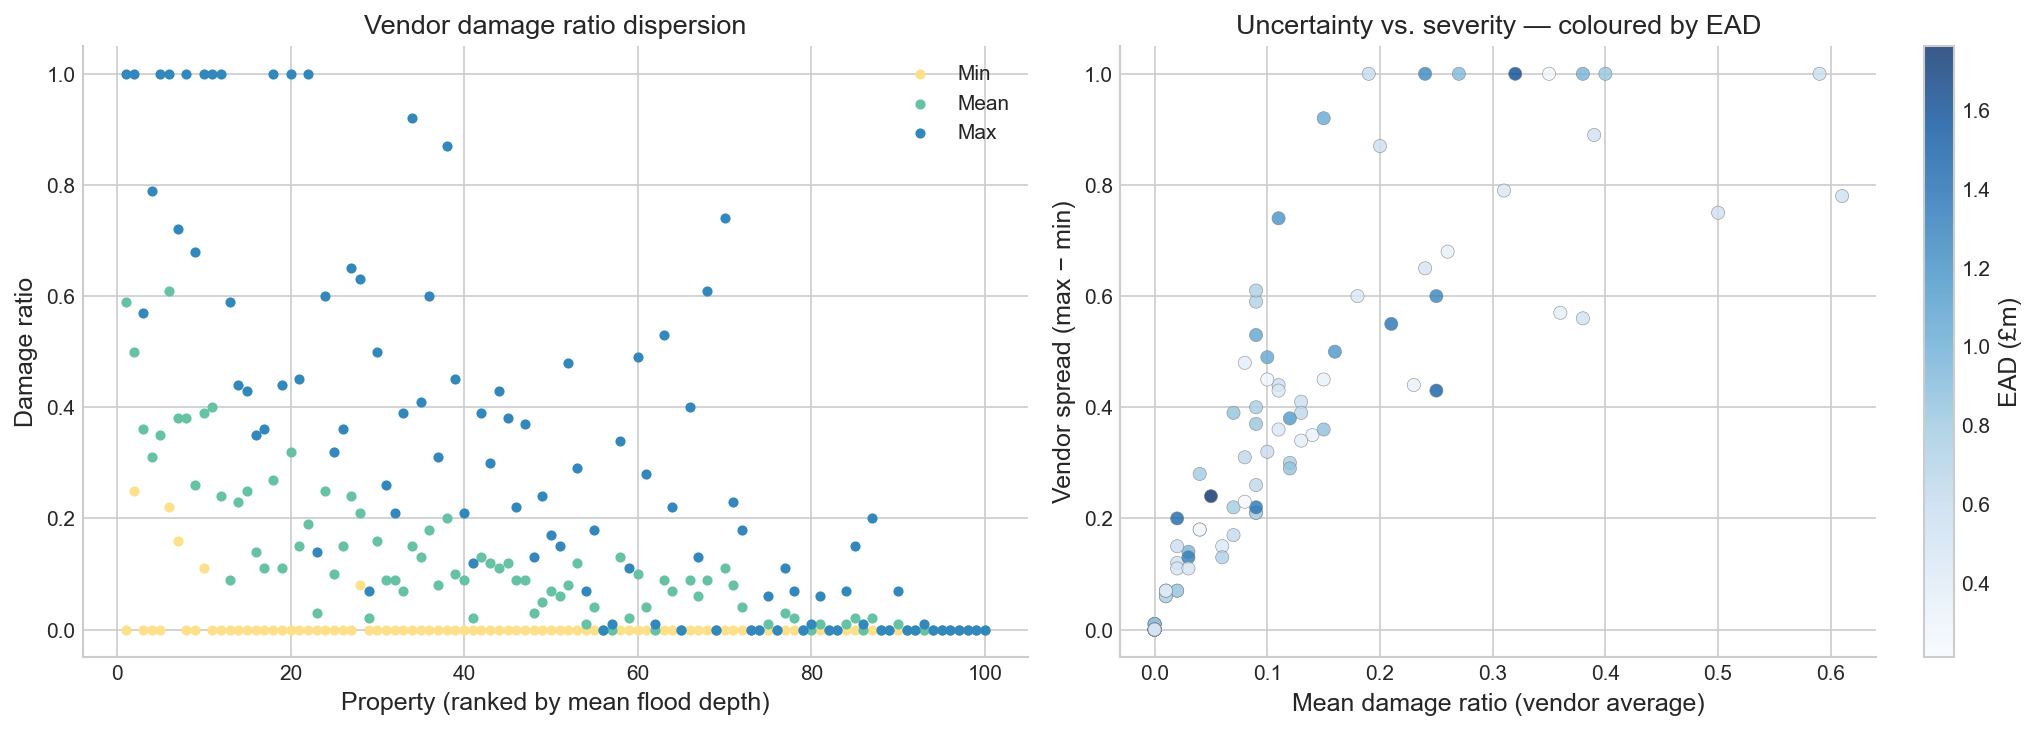

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: vendor min/mean/max across properties (sorted by mean DR)
ax = axes[0]
x = portfolio.property_rank
ax.scatter(x, portfolio.d_min,  c=COLOURS["data_min"],  s=15, label="Min",  zorder=3)
ax.scatter(x, portfolio.d_mean, c=COLOURS["data_mean"], s=15, label="Mean", zorder=3)
ax.scatter(x, portfolio.d_max,  c=COLOURS["data_max"],  s=15, label="Max",  zorder=3)
ax.set_xlabel("Property (ranked by mean flood depth)")
ax.set_ylabel("Damage ratio")
ax.set_title("Vendor damage ratio dispersion")
ax.legend()

# Right: vendor spread vs. mean DR — shows where uncertainty is concentrated
ax = axes[1]
sc = ax.scatter(
    portfolio.d_mean,
    portfolio.vendor_spread,
    c=portfolio.ead_m,
    cmap="Blues",
    s=40,
    alpha=0.8,
    edgecolors="grey",
    linewidths=0.3,
    zorder=3
)
plt.colorbar(sc, ax=ax, label="EAD (£m)")
ax.set_xlabel("Mean damage ratio (vendor average)")
ax.set_ylabel("Vendor spread (max − min)")
ax.set_title("Uncertainty vs. severity — coloured by EAD")

plt.tight_layout()
plt.savefig("../../outputs/figures/shared/portfolio_physical_risk_profile.png")
plt.show()

## 6. Baseline ECL distribution (pre-climate, Stage 1)

C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\2765313005.py:30: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\2765313005.py:30: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\2765313005.py:31: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/shared/portfolio_baseline_ecl.png", dpi=300,
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\2765313005.py:31: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/shared/portfolio_baseline_ecl.png", dpi=300,
C:\Users\Mark.DESKTOP-UFHIN6T\anaconda3\envs\garp-climate-risk\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing f

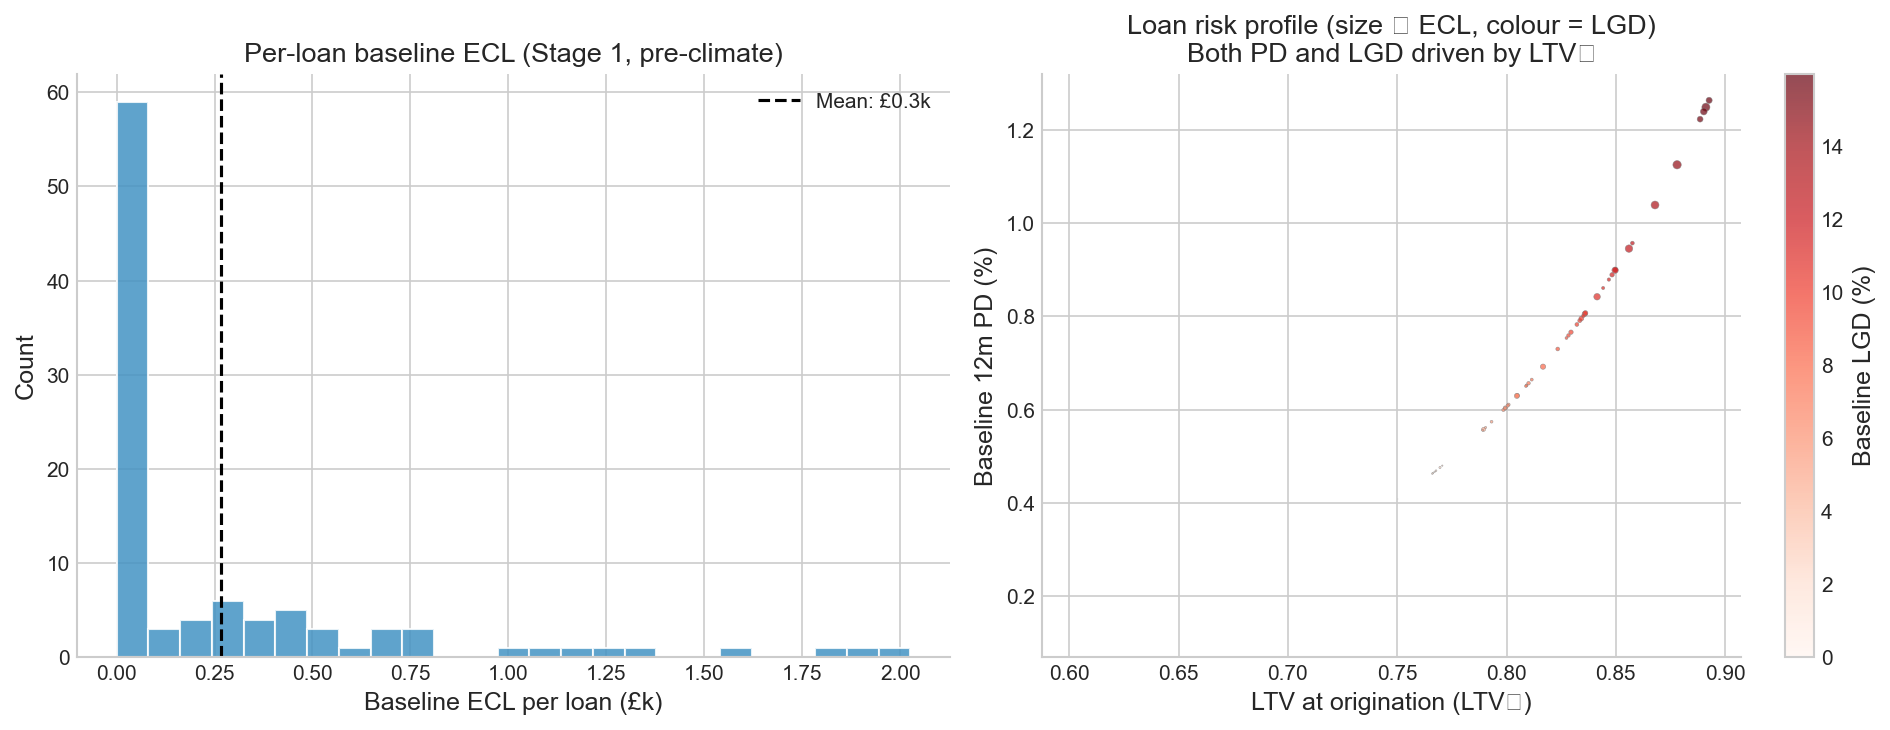

Total portfolio EAD:          £69.3m
Total baseline ECL (Stage 1): £26.5k
ECL / EAD (basis points):     3.83bp


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Per-loan baseline ECL in £k
ax = axes[0]
ecl_k = portfolio.baseline_ecl_m * 1000
ax.hist(ecl_k, bins=25, color=COLOURS["stage1"], edgecolor="white", alpha=0.85)
ax.axvline(ecl_k.mean(), color="k", lw=1.5, ls="--", label=f"Mean: £{ecl_k.mean():.1f}k")
ax.set_xlabel("Baseline ECL per loan (£k)")
ax.set_ylabel("Count")
ax.set_title("Per-loan baseline ECL (Stage 1, pre-climate)")
ax.legend()

# ECL vs LTV₀ — the structural relationship
ax = axes[1]
sc = ax.scatter(
    portfolio.ltv_0,
    portfolio.baseline_pd_12m * 100,
    c=portfolio.baseline_lgd * 100,
    cmap="Reds",
    s=portfolio.baseline_ecl_m * 8000,
    alpha=0.7,
    edgecolors="grey",
    linewidths=0.3,
)
plt.colorbar(sc, ax=ax, label="Baseline LGD (%)")
ax.set_xlabel("LTV at origination (LTV₀)")
ax.set_ylabel("Baseline 12m PD (%)")
ax.set_title("Loan risk profile (size ∝ ECL, colour = LGD)\nBoth PD and LGD driven by LTV₀")

plt.tight_layout()
plt.savefig("../../outputs/figures/shared/portfolio_baseline_ecl.png", dpi=300,
            bbox_inches="tight")
plt.show()

print(f"Total portfolio EAD:          £{portfolio.ead_m.sum():.1f}m")
print(f"Total baseline ECL (Stage 1): £{portfolio.baseline_ecl_m.sum()*1000:.1f}k")
print(f"ECL / EAD (basis points):     {portfolio.baseline_ecl_m.sum() / portfolio.ead_m.sum() * 10000:.2f}bp")

## 7. SICR staging sensitivity — vendor uncertainty vs. LTV₀

The SICR threshold fires when a loan's lifetime PD more than doubles relative to baseline (EBA doubling rule, τ=2). Under the LTV structural model:
- The threshold damage ratio d* is **pre-computed per loan** in `build_portfolio()` via numerical root-finding
- Loans with high LTV₀ are closer to the logistic inflection point → smaller damage needed to trigger SICR
- This creates a direct link between LTV₀ heterogeneity and sensitivity to vendor disagreement

In [9]:
tau = config["decision1_credit_risk"]["sicr_threshold"]

# d_sicr_threshold already computed by build_portfolio() — just read it
triggered_by_mean = portfolio.d_mean >= portfolio.d_sicr_threshold
triggered_by_max  = portfolio.d_max  >= portfolio.d_sicr_threshold
unreachable       = portfolio.d_sicr_threshold.isna()
straddles         = triggered_by_max & ~triggered_by_mean & ~unreachable

print(f"=== SICR sensitivity preview (LTV structural model, τ={tau}) ===")
print(f"\nLoans where SICR threshold is unreachable (d* > 1):  {unreachable.sum()}")
print(f"Loans triggered by mean vendor estimate:             {triggered_by_mean.sum()}")
print(f"Loans triggered by max vendor estimate:              {triggered_by_max.sum()}")
print(f"Vendor band straddles threshold (key uncertainty):   {straddles.sum()}")
print(f"\nInterpretation: for {straddles.sum()} loans, the choice of vendor determines")
print(f"whether the loan is in Stage 1 or Stage 2 — a potentially large ECL difference.")

=== SICR sensitivity preview (LTV structural model, τ=2.0) ===

Loans where SICR threshold is unreachable (d* > 1):  0
Loans triggered by mean vendor estimate:             36
Loans triggered by max vendor estimate:              66
Vendor band straddles threshold (key uncertainty):   30

Interpretation: for 30 loans, the choice of vendor determines
whether the loan is in Stage 1 or Stage 2 — a potentially large ECL difference.


C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\3663176516.py:61: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_30288\3663176516.py:62: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/shared/portfolio_sicr_threshold_preview.png", dpi=300,


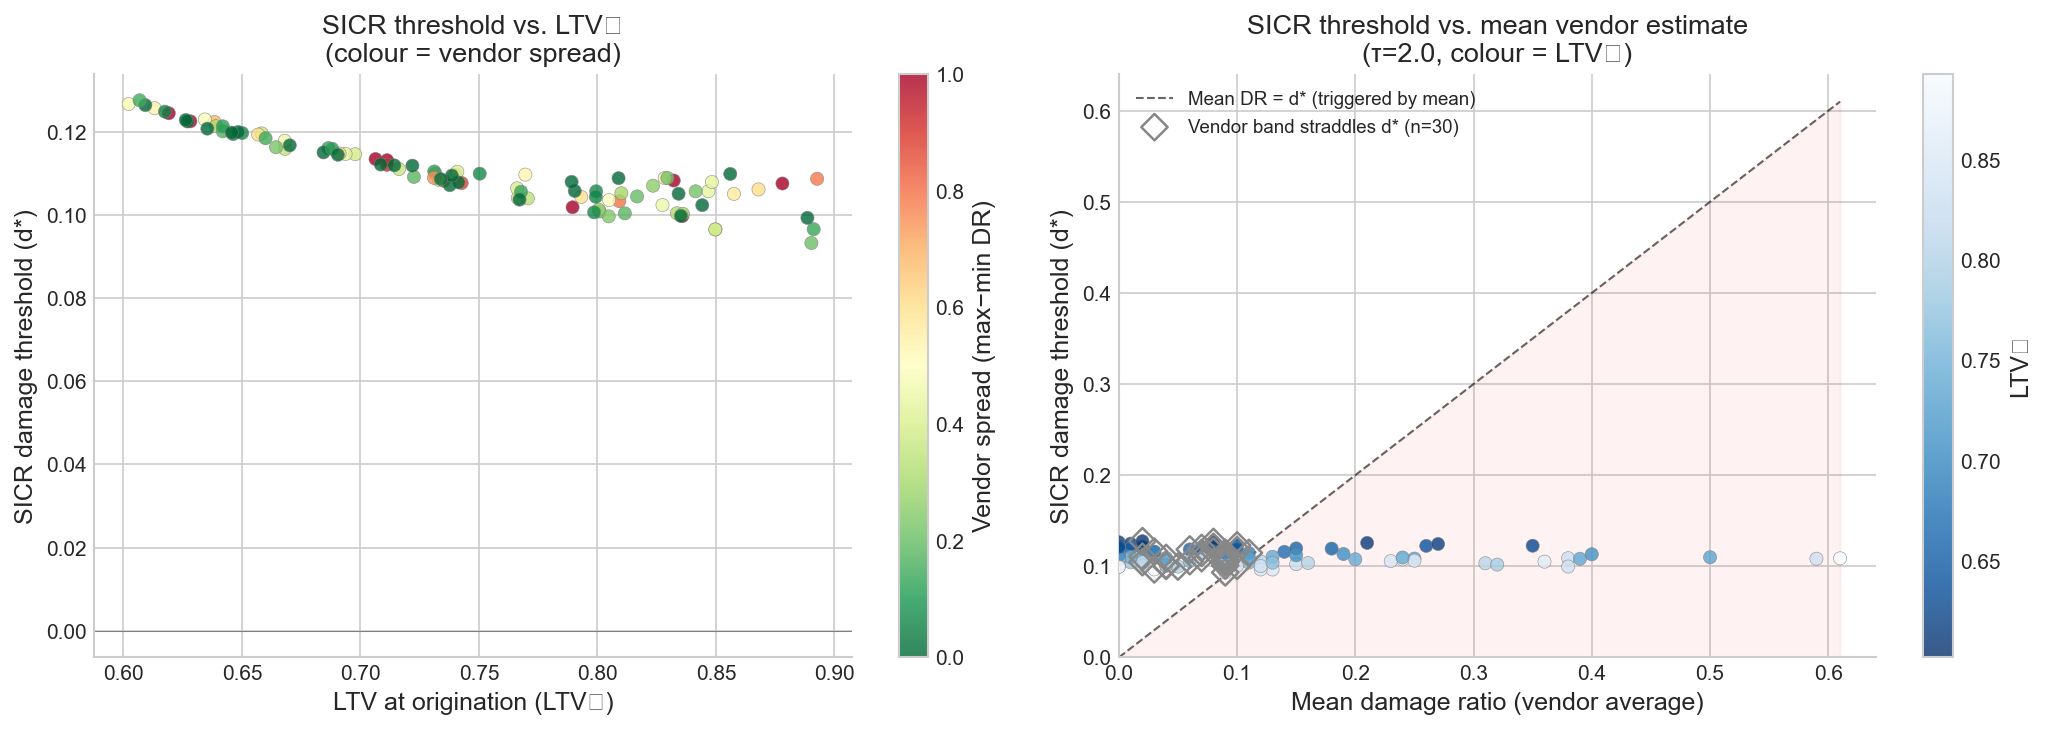

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid = portfolio.d_sicr_threshold.notna()

# --- Left: d* vs LTV₀ — shows structural relationship ---
ax = axes[0]
sc = ax.scatter(
    portfolio.loc[valid, "ltv_0"],
    portfolio.loc[valid, "d_sicr_threshold"],
    c=portfolio.loc[valid, "vendor_spread"],
    cmap="RdYlGn_r",
    s=40,
    alpha=0.8,
    edgecolors="grey",
    linewidths=0.3,
    zorder=3,
)
plt.colorbar(sc, ax=ax, label="Vendor spread (max−min DR)")
ax.set_xlabel("LTV at origination (LTV₀)")
ax.set_ylabel("SICR damage threshold (d*)")
ax.set_title("SICR threshold vs. LTV₀\n(colour = vendor spread)")
ax.axhline(0, color="grey", lw=0.5)

# --- Right: d* vs mean DR — shows where staging uncertainty is concentrated ---
ax = axes[1]
lim = max(
    portfolio.loc[valid, ["d_mean", "d_sicr_threshold"]].max().max(),
    0.1
)
sc2 = ax.scatter(
    portfolio.loc[valid, "d_mean"],
    portfolio.loc[valid, "d_sicr_threshold"],
    c=portfolio.loc[valid, "ltv_0"],
    cmap="Blues_r",
    s=40,
    alpha=0.8,
    edgecolors="grey",
    linewidths=0.3,
    zorder=3,
)
plt.colorbar(sc2, ax=ax, label="LTV₀")

ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.6, label="Mean DR = d* (triggered by mean)")
ax.fill_between([0, lim], [0, 0], [0, lim], alpha=0.05, color="red")

# Mark the "straddles" loans
ax.scatter(
    portfolio.loc[straddles, "d_mean"],
    portfolio.loc[straddles, "d_sicr_threshold"],
    s=80, marker="D", facecolors="none", edgecolors=COLOURS["threshold"],
    linewidths=1.2, zorder=4, label=f"Vendor band straddles d* (n={straddles.sum()})"
)

ax.set_xlabel("Mean damage ratio (vendor average)")
ax.set_ylabel("SICR damage threshold (d*)")
ax.set_title(f"SICR threshold vs. mean vendor estimate\n(τ={tau}, colour = LTV₀)")
ax.legend(fontsize=9)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("../../outputs/figures/shared/portfolio_sicr_threshold_preview.png", dpi=300,
            bbox_inches="tight")
plt.show()

## 8. Save portfolio

In [11]:
portfolio.to_csv("../../data/processed/portfolio.csv", index=False)

print("Saved: data/processed/portfolio.csv")
print(f"Shape: {portfolio.shape}")
print(f"\nColumns:")
for col in portfolio.columns:
    print(f"  {col}")

Saved: data/processed/portfolio.csv
Shape: (100, 23)

Columns:
  property_rank
  d_min
  d_mean
  d_max
  vendor_spread
  is_zero_damage
  tri_mode
  tri_clamped
  ltv_0
  pv_0_m
  maturity_years
  ead_m
  baseline_pd_12m
  baseline_lgd
  baseline_pd_lt
  baseline_ecl_m
  d_sicr_threshold
  d_sicr_uncond
  ead_rf_m
  baseline_pd_rf
  baseline_lgd_rf
  baseline_pd_lt_rf
  baseline_ecl_rf_m


## 9. Notes for downstream notebooks

**Portfolio schema** — `portfolio.csv` contains one row per loan/property:

| Column | Type | Description |
|--------|------|-------------|
| `property_rank` | int | Links back to CFRF/GARP physical risk data |
| `d_min / d_mean / d_max` | float | Vendor min/mean/max damage ratio |
| `vendor_spread` | float | d_max − d_min |
| `is_zero_damage` | bool | True for 20 properties with no flood damage |
| `tri_mode / tri_clamped` | float/bool | Triangular fit parameters from Notebook 01 |
| `ltv_0` | float | **Primary draw**: LTV at origination ~ Uniform(0.60, 0.90) |
| `pv_0_m` | float | **Primary draw**: Property value (£m) ~ Lognormal |
| `maturity_years` | int | **Primary draw**: Loan term ~ discrete Uniform(5, 25) |
| `ead_m` | float | **Derived**: EAD = LTV₀ × PV₀ (£m) |
| `baseline_pd_12m` | float | **Derived**: logistic(β₀ + β₁ × LTV₀) |
| `baseline_lgd` | float | **Derived**: max(1 − (1−ω)/LTV₀, 0) at d=0 |
| `baseline_pd_lt` | float | **Derived**: 1 − (1 − PD₁₂m)ᵀ |
| `baseline_ecl_m` | float | **Derived**: PD₁₂m × LGD × EAD (£m, Stage 1) |
| `d_sicr_threshold` | float | **Derived**: damage ratio at which SICR fires; NaN if unreachable |
| `ead_rf_m` | float | **Sensitivity RF**: independent EAD draw (£m) |
| `baseline_pd_rf` | float | **Sensitivity RF**: independent PD draw |
| `baseline_lgd_rf` | float | **Sensitivity RF**: independent LGD draw |
| `baseline_pd_lt_rf` | float | **Sensitivity RF**: derived lifetime PD |
| `baseline_ecl_rf_m` | float | **Sensitivity RF**: ECL under reduced-form model (£m) |

**Key structural properties of this portfolio**:
- PD and LGD are **not independent** — both are functions of the same LTV₀. This is the defining feature of the structural model.
- Loans with LTV₀ < (1−ω) = 0.75 have baseline LGD = 0; climate damage pushes them into positive LGD territory.
- The SICR threshold d* is **smaller for high-LTV₀ loans** — they require less climate damage to trigger Stage 2. This is the mechanism through which vendor disagreement on damage ratios translates into disagreement on ECL.

**Next step**: Notebook 03 maps the full d → PD/LGD/ECL transmission curves; Notebook 04 runs the Monte Carlo simulation.